# Heating Process

## Energy Balances
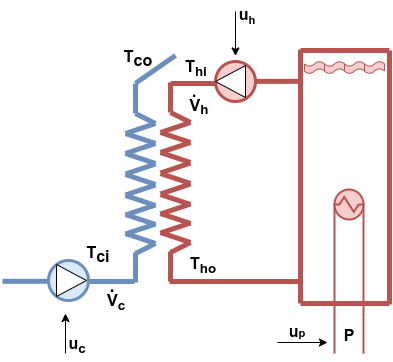



In [1]:
import os 
import random
import torch
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import train_test_split

## Remove randomness from the notebook

In [2]:
def remove_randomness(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.set_num_threads(1) 
    torch.set_num_interop_threads(1)
    if platform.processor() == 'arm':
        torch.mps.manual_seed(seed)

seed = 1042
remove_randomness(seed)

def seed_worker(worker_id):
    worker_seed = seed + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

## Colab

In [3]:
# from google.colab import files
# files.upload()

## Loading data

In [4]:
if platform.system() == 'Windows':
    !dir
else:
    !ls

BPNN_model.pth                      PRBS.csv
FNNR_model.pth                      Structured-abstact.pdf
Heat_Process_Model_Final V1         Structured-abstract.docx
Heat_Process_Model_Final V1.ipynb   V_c_comparison_plot.png
Heat_Process_Model_Final V1.pdf     best_model.pth
Heat_Process_Model_Final V1.zip     best_model_pv.pth
Heat_Process_Testing_Final V1       figures
Heat_Process_Testing_Final V1.ipynb multSineExp 1.csv
Heat_Process_Testing_Final V1.pdf   paper.log
Heat_Process_Testing_Final V1.zip   paper.pdf
Heat_Process_Variables_Final        paper.synctex.gz
Heat_Process_Variables_Final.ipynb  paper.tex
Heat_Process_Variables_Final.pdf    references.bib
Heat_Process_Variables_Final.zip    splncs03.bst
PBN_model.pth                       svproc.cls


In [5]:
# Reading the data
df = pd.read_csv('PRBS.csv', delimiter=";")
df.head()

,0.00E+00,0.00E+00.1,0.00E+00.2,0.00E+00.3,0.00E+00.4,0.00E+00.5,0.00E+00.6,0.00E+00.7,0.00E+00.8,0.00E+00.9
0,0.0,0.000,0.00000,0.0000,0.0000,0.0733,0.0733,1.0,1.0,25.0
1,0.0,0.000,0.00000,0.0733,0.0000,0.0000,-0.0733,2.0,2.0,25.0
2,0.0,-0.244,-0.00122,-0.0733,0.0000,0.0000,0.0733,3.0,3.0,25.0
3,0.0,0.000,0.00000,0.0733,0.0733,0.0733,0.0000,4.0,4.0,25.0
4,0.0,0.000,0.00000,0.0000,0.0000,-0.0733,0.0000,5.0,5.0,25.0


In [6]:
df.columns = ['L_in', 'V_c [ml/min]', 'P [kW]', 'T_ho [°C]', 'T_hi [°C]', 'T_ci [°C]', 'T_co [°C]', 'u_c [%]', 'u_h [%]', 'u_p [%]']

In [7]:
df.describe()

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%]
count,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000,14399.000000
mean,19.169327,33.413782,0.079282,5.171392,7.649166,1.847576,5.631319,10.910966,9.456768,4.803806
std,46.610022,78.871288,0.213907,11.883784,17.490006,4.207372,12.881252,25.462560,22.704181,13.054138
min,0.000000,-0.244000,-0.001220,-0.073300,-0.073300,-0.073300,-0.073300,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,219.000000,287.000000,1.580000,43.300000,57.600000,16.600000,45.700000,80.000000,80.000000,95.000000


<Axes: >

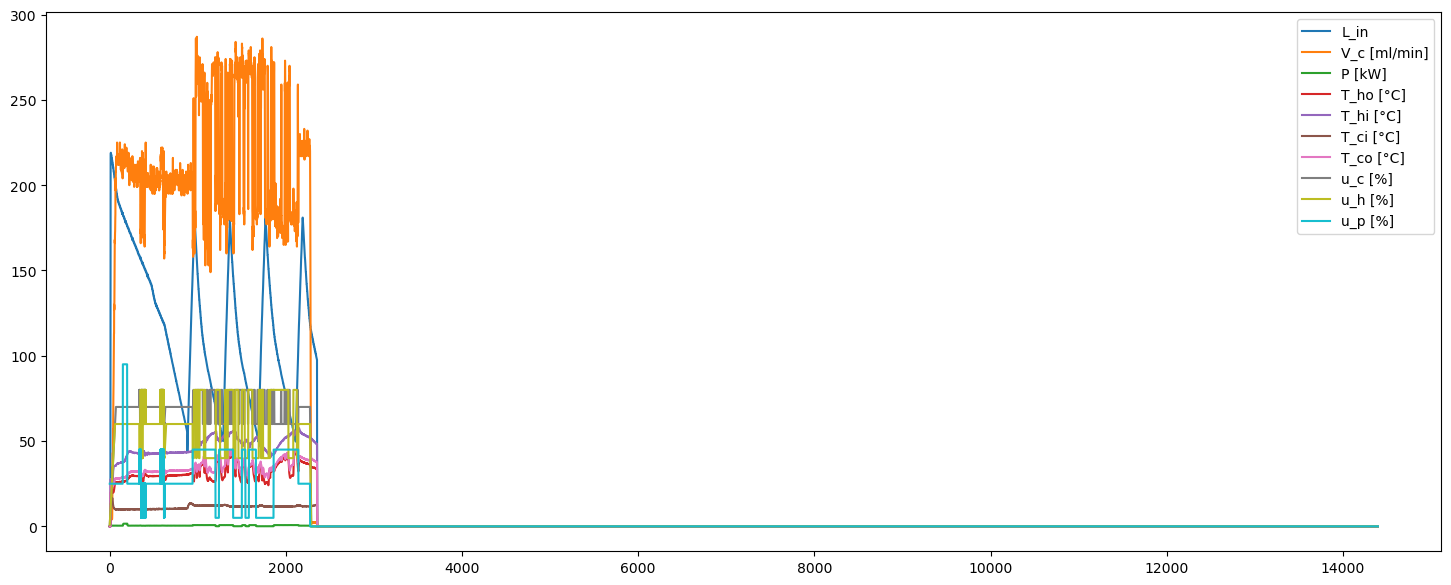

In [8]:
df.plot(figsize = [18,7])

In [9]:
start = 942
end = 2143
df = df[start:end]
len(df)

1201

In [10]:
df = df.reset_index(drop=True)

<Axes: >

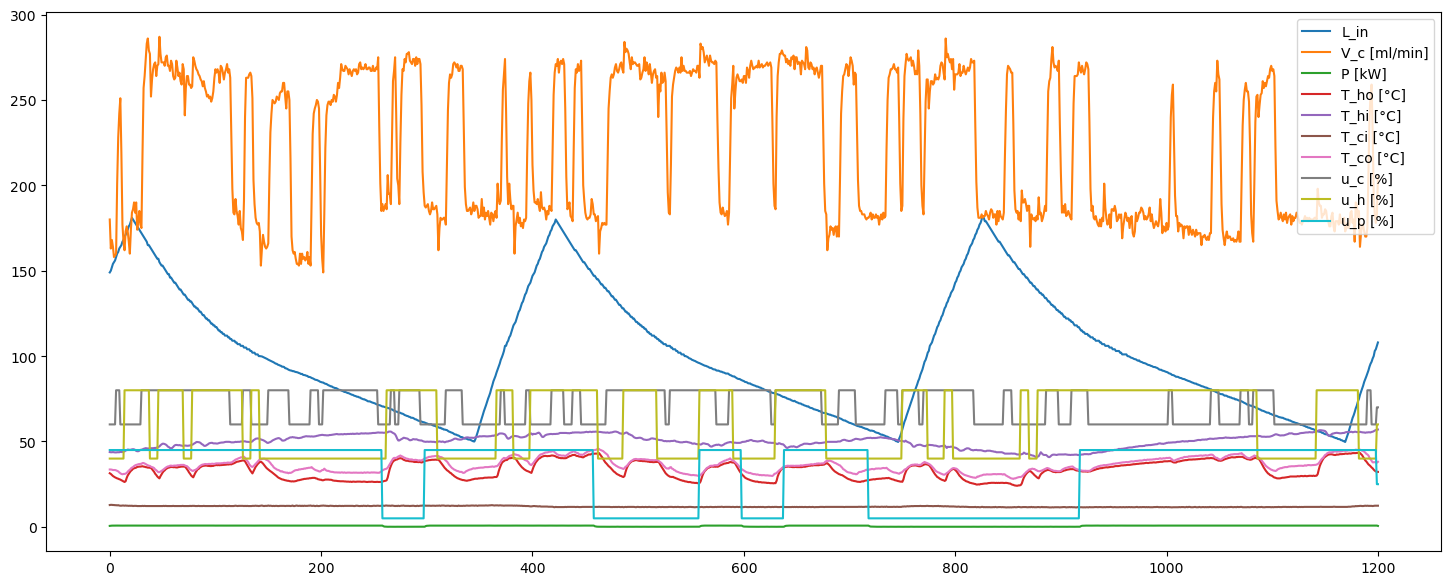

In [11]:
df.plot(figsize = [18,7])

## Creating shifted variables

In [12]:
df['T_ho_k+1 [°C]'] = df['T_ho [°C]'].shift(-1)
df['T_hi_k+1 [°C]'] = df['T_hi [°C]'].shift(-1)
df['T_co_k+1 [°C]'] = df['T_co [°C]'].shift(-1)

In [13]:
df = df.ffill()
df = df.bfill()

df

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%],T_ho_k+1 [°C],T_hi_k+1 [°C],T_co_k+1 [°C]
0,149.0,180.0,0.590,31.4,43.8,12.8,33.6,60.0,40.0,45.0,31.0,43.7,33.6
1,150.0,163.0,0.675,31.0,43.7,12.9,33.6,60.0,40.0,45.0,30.4,43.7,33.5
2,152.0,168.0,0.725,30.4,43.7,12.9,33.5,60.0,40.0,45.0,29.8,43.8,33.3
3,154.0,164.0,0.741,29.8,43.8,12.8,33.3,60.0,40.0,45.0,29.4,43.7,33.3
4,155.0,158.0,0.733,29.4,43.7,12.8,33.3,60.0,40.0,45.0,29.0,43.6,33.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,100.0,195.0,0.736,33.5,56.0,12.3,37.8,60.0,40.0,45.0,32.9,56.4,37.9
1197,103.0,183.0,0.727,32.9,56.4,12.4,37.9,60.0,40.0,45.0,32.5,56.7,37.9
1198,104.0,178.0,0.741,32.5,56.7,12.4,37.9,60.0,40.0,45.0,32.2,56.9,37.6
1199,106.0,183.0,0.752,32.2,56.9,12.4,37.6,70.0,60.0,25.0,32.2,57.0,38.1


## From control signals to process variables

In [14]:
# P [kW] based on new identification
K = 0.016448197219320244
T = 1.6774198321721923
Ts = 1.0
u_min = 0.0

# Initialize the column with NaN
df['P_est [kW]'] = float('nan')
# Set the initial value for the column (e.g., 0 for the first row)
df.at[0, 'P_est [kW]'] = 0.59  # You can choose any starting value for the first row
# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'P_est [kW]'] = Ts*K/T*np.maximum(df.at[i-1, 'u_p [%]']-u_min, 0.0)  + (1-Ts/T)*df.at[i-1, 'P_est [kW]']

In [15]:
# V_h [ml/min] based on old identification
K = 10.0 
T = 1.0 
Ts = 1.0
u_min = 19.0

# Initialize the column with NaN
df['V_h_est [ml/min]'] = float('nan')
# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_h_est [ml/min]'] = 300  # You can choose any starting value for the first row
# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_h_est [ml/min]'] = Ts*K/T*np.maximum(df.at[i-1, 'u_h [%]']-u_min, 0.0) + (1-Ts/T)*df.at[i-1, 'V_h_est [ml/min]']

In [16]:
# V_c [ml/min]
K = 4.542787080789755
T = 2.3955179532313875
Ts = 1.0
u_min = 20.35188865661621

# Initialize the column with NaN
df['V_c_est [ml/min]'] = float('nan')
# Set the initial value for the 'new' column (e.g., 0 for the first row)
df.at[0, 'V_c_est [ml/min]'] = 180  # You can choose any starting value for the first row
# Loop through rows starting from the second row
for i in range(1, len(df)):
    df.at[i, 'V_c_est [ml/min]'] = Ts*K/T*np.maximum(df.at[i-1, 'u_c [%]']-u_min,0.0) + (1-Ts/T)*df.at[i-1, 'V_c_est [ml/min]']

In [17]:
df['P_est_k+1 [kW]'] = df['P_est [kW]'].shift(-1)
df['V_h_est_k+1 [ml/min]'] = df['V_h_est [ml/min]'].shift(-1)
df['V_c_est_k+1 [ml/min]'] = df['V_c_est [ml/min]'].shift(-1)

df['P_est_k-1 [kW]'] = df['P_est [kW]'].shift(1)
df['V_h_est_k-1 [ml/min]'] = df['V_h_est [ml/min]'].shift(1)
df['V_c_est_k-1 [ml/min]'] = df['V_c_est [ml/min]'].shift(1)

df['P_k+1 [kW]'] = df['P [kW]'].shift(-1)
df['V_c_k+1 [ml/min]'] = df['V_c [ml/min]'].shift(-1)

In [18]:
df = df.ffill()
df = df.bfill()

df

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%],...,V_h_est [ml/min],V_c_est [ml/min],P_est_k+1 [kW],V_h_est_k+1 [ml/min],V_c_est_k+1 [ml/min],P_est_k-1 [kW],V_h_est_k-1 [ml/min],V_c_est_k-1 [ml/min],P_k+1 [kW],V_c_k+1 [ml/min]
0,149.0,180.0,0.590,31.4,43.8,12.8,33.6,60.0,40.0,45.0,...,300.0,180.000000,0.679524,210.0,180.047141,0.590000,300.0,180.000000,0.675,163.0
1,150.0,163.0,0.675,31.0,43.7,12.9,33.6,60.0,40.0,45.0,...,210.0,180.047141,0.715678,210.0,180.074604,0.590000,300.0,180.000000,0.725,168.0
2,152.0,168.0,0.725,30.4,43.7,12.9,33.5,60.0,40.0,45.0,...,210.0,180.074604,0.730278,210.0,180.090602,0.679524,210.0,180.047141,0.741,164.0
3,154.0,164.0,0.741,29.8,43.8,12.8,33.3,60.0,40.0,45.0,...,210.0,180.090602,0.736175,210.0,180.099922,0.715678,210.0,180.074604,0.733,158.0
4,155.0,158.0,0.733,29.4,43.7,12.8,33.3,60.0,40.0,45.0,...,210.0,180.099922,0.738556,210.0,180.105351,0.730278,210.0,180.090602,0.736,159.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1196,100.0,195.0,0.736,33.5,56.0,12.3,37.8,60.0,40.0,45.0,...,210.0,207.395393,0.740169,210.0,196.006430,0.740169,210.0,226.945457,0.727,183.0
1197,103.0,183.0,0.727,32.9,56.4,12.4,37.9,60.0,40.0,45.0,...,210.0,196.006430,0.740169,210.0,189.371747,0.740169,210.0,207.395393,0.741,178.0
1198,104.0,178.0,0.741,32.5,56.7,12.4,37.9,60.0,40.0,45.0,...,210.0,189.371747,0.740169,210.0,185.506688,0.740169,210.0,196.006430,0.752,183.0
1199,106.0,183.0,0.752,32.2,56.9,12.4,37.6,70.0,60.0,25.0,...,210.0,185.506688,0.544056,410.0,202.218778,0.740169,210.0,189.371747,0.562,205.0


<Axes: >

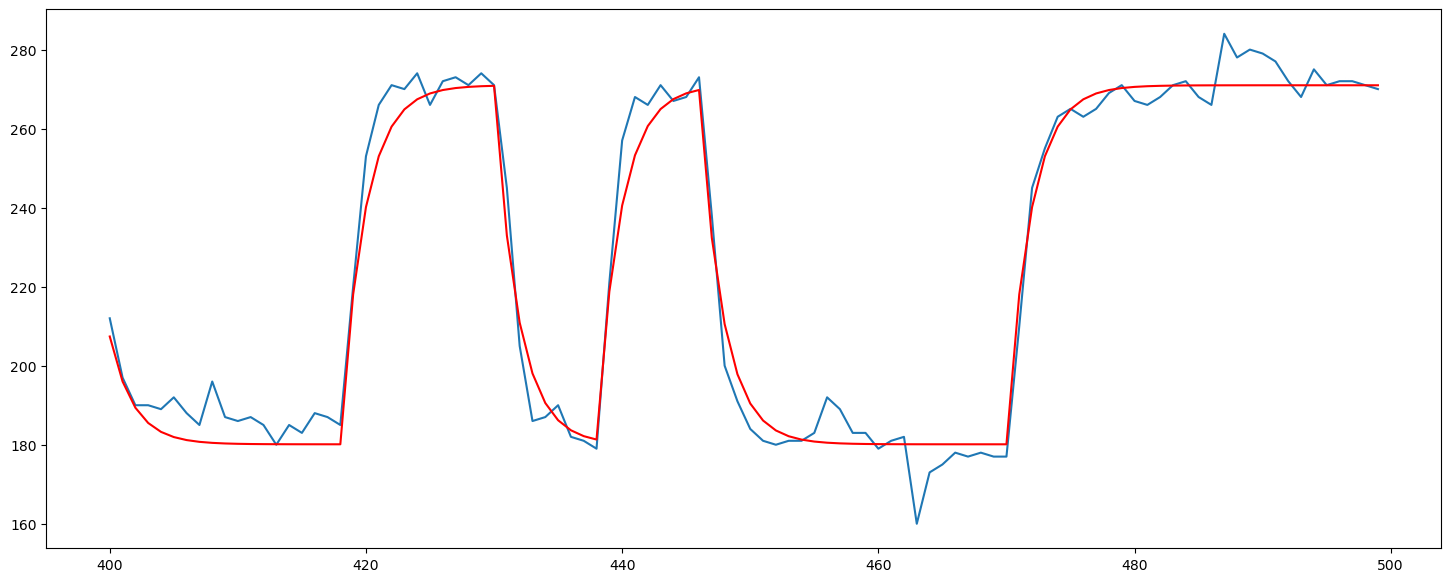

In [19]:
df[400:500]['V_c [ml/min]'].plot()
df[400:500]['V_c_est [ml/min]'].plot(color = 'red', figsize = [18,7])

<Axes: >

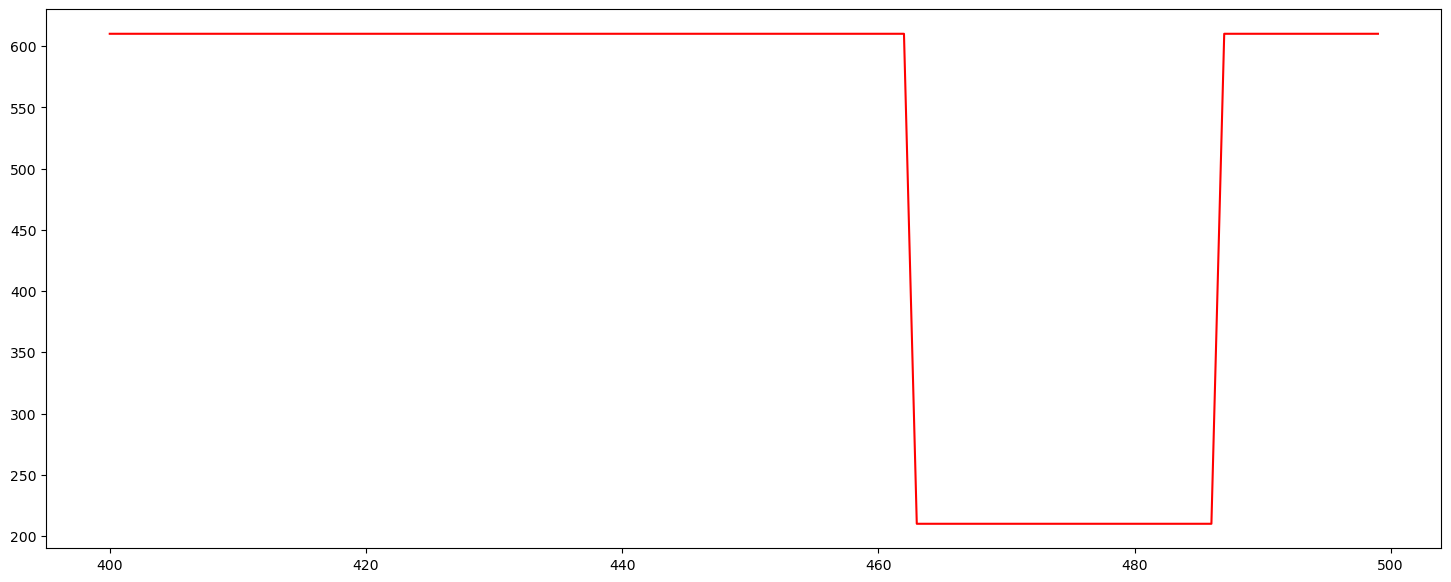

In [20]:
df[400:500]['V_h_est [ml/min]'].plot(color = 'red', figsize = [18,7])

<Axes: >

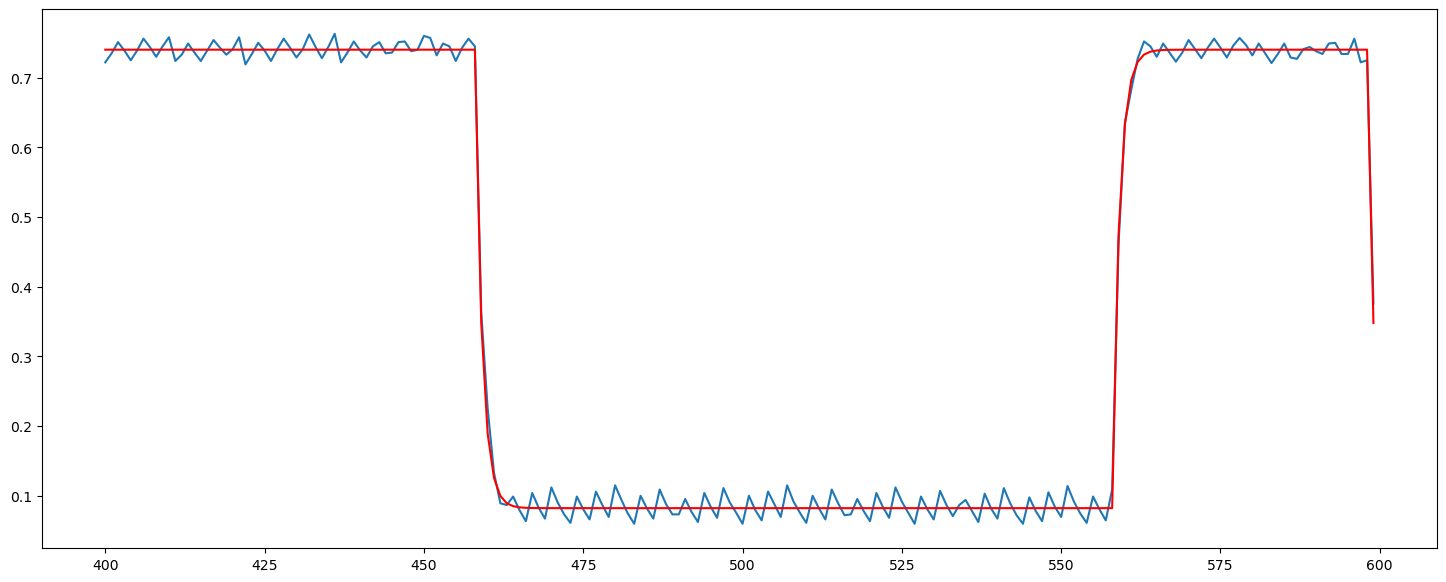

In [21]:
df[400:600]['P [kW]'].plot()
df[400:600]['P_est [kW]'].plot(color = 'red', figsize = [18,7])

## Checking data

In [22]:
# Missing values
df.isna().sum()

L_in                    0
V_c [ml/min]            0
P [kW]                  0
T_ho [°C]               0
T_hi [°C]               0
T_ci [°C]               0
T_co [°C]               0
u_c [%]                 0
u_h [%]                 0
u_p [%]                 0
T_ho_k+1 [°C]           0
T_hi_k+1 [°C]           0
T_co_k+1 [°C]           0
P_est [kW]              0
V_h_est [ml/min]        0
V_c_est [ml/min]        0
P_est_k+1 [kW]          0
V_h_est_k+1 [ml/min]    0
V_c_est_k+1 [ml/min]    0
P_est_k-1 [kW]          0
V_h_est_k-1 [ml/min]    0
V_c_est_k-1 [ml/min]    0
P_k+1 [kW]              0
V_c_k+1 [ml/min]        0
dtype: int64

In [23]:
# Check the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   L_in                  1201 non-null   float64
 1   V_c [ml/min]          1201 non-null   float64
 2   P [kW]                1201 non-null   float64
 3   T_ho [°C]             1201 non-null   float64
 4   T_hi [°C]             1201 non-null   float64
 5   T_ci [°C]             1201 non-null   float64
 6   T_co [°C]             1201 non-null   float64
 7   u_c [%]               1201 non-null   float64
 8   u_h [%]               1201 non-null   float64
 9   u_p [%]               1201 non-null   float64
 10  T_ho_k+1 [°C]         1201 non-null   float64
 11  T_hi_k+1 [°C]         1201 non-null   float64
 12  T_co_k+1 [°C]         1201 non-null   float64
 13  P_est [kW]            1201 non-null   float64
 14  V_h_est [ml/min]      1201 non-null   float64
 15  V_c_est [ml/min]     

## Device, features and targets

In [24]:
# Device
if torch.backends.mps.is_available():
    device ='mps'
elif torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'
device

'mps'

In [25]:
# Scaling
# df['T_hi_k+1 [°C]'] = 10.0 * df['T_hi_k+1 [°C]']

In [26]:
features = ['u_p [%]', 'P_est [kW]',# 'P_est [kW]', 
            'u_c [%]', 'V_c_est [ml/min]',# 'V_c_est [ml/min]', 
            'u_h [%]', 'V_h_est [ml/min]', 
            'T_hi [°C]', 'T_ho [°C]', 'T_ci [°C]', 'T_co [°C]']
targets = ['P_est_k+1 [kW]', 'V_c_est_k+1 [ml/min]', 'V_h_est_k+1 [ml/min]', 
           'T_hi_k+1 [°C]','T_ho_k+1 [°C]','T_co_k+1 [°C]']

In [27]:
features

['u_p [%]',
 'P_est [kW]',
 'u_c [%]',
 'V_c_est [ml/min]',
 'u_h [%]',
 'V_h_est [ml/min]',
 'T_hi [°C]',
 'T_ho [°C]',
 'T_ci [°C]',
 'T_co [°C]']

In [28]:
targets

['P_est_k+1 [kW]',
 'V_c_est_k+1 [ml/min]',
 'V_h_est_k+1 [ml/min]',
 'T_hi_k+1 [°C]',
 'T_ho_k+1 [°C]',
 'T_co_k+1 [°C]']

## Loading data

In [29]:
# split data in training, validation and test dataset 70 %, 15%, 15%
train_df, test_df = train_test_split(df,train_size=0.7, shuffle = False, random_state = seed)
valid_df, test_df = train_test_split(test_df,train_size=0.5, shuffle = False, random_state = seed)

In [30]:
train_df.head()

,L_in,V_c [ml/min],P [kW],T_ho [°C],T_hi [°C],T_ci [°C],T_co [°C],u_c [%],u_h [%],u_p [%],...,V_h_est [ml/min],V_c_est [ml/min],P_est_k+1 [kW],V_h_est_k+1 [ml/min],V_c_est_k+1 [ml/min],P_est_k-1 [kW],V_h_est_k-1 [ml/min],V_c_est_k-1 [ml/min],P_k+1 [kW],V_c_k+1 [ml/min]
0,149.0,180.0,0.590,31.4,43.8,12.8,33.6,60.0,40.0,45.0,...,300.0,180.000000,0.679524,210.0,180.047141,0.590000,300.0,180.000000,0.675,163.0
1,150.0,163.0,0.675,31.0,43.7,12.9,33.6,60.0,40.0,45.0,...,210.0,180.047141,0.715678,210.0,180.074604,0.590000,300.0,180.000000,0.725,168.0
2,152.0,168.0,0.725,30.4,43.7,12.9,33.5,60.0,40.0,45.0,...,210.0,180.074604,0.730278,210.0,180.090602,0.679524,210.0,180.047141,0.741,164.0
3,154.0,164.0,0.741,29.8,43.8,12.8,33.3,60.0,40.0,45.0,...,210.0,180.090602,0.736175,210.0,180.099922,0.715678,210.0,180.074604,0.733,158.0
4,155.0,158.0,0.733,29.4,43.7,12.8,33.3,60.0,40.0,45.0,...,210.0,180.099922,0.738556,210.0,180.105351,0.730278,210.0,180.090602,0.736,159.0


In [31]:
# Dataset
from torch.utils.data import Dataset
class MyDataset(Dataset):

  def __init__(self,df,features, targets):
    self.X=torch.tensor(df[features].values, dtype=torch.float32)
    self.y=torch.tensor(df[targets].values,dtype=torch.float32)

  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx):
    return self.X[idx], self.y[idx]

In [32]:
# Dataloader
from torch.utils.data import DataLoader

train_myDs=MyDataset(train_df, features, targets)
train_dataloader = DataLoader(train_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

valid_myDs=MyDataset(valid_df, features, targets)
valid_dataloader = DataLoader(valid_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

test_myDs=MyDataset(test_df, features, targets)
test_dataloader = DataLoader(test_myDs,batch_size=512,shuffle=True, worker_init_fn=seed_worker)

## Models

In [33]:
# model for the neural network
class NNModel(torch.nn.Module):
    def __init__(self, drop):
        super(NNModel, self).__init__()
        self.linear1 = torch.nn.Linear(10, 16)
        self.linear2 = torch.nn.Linear(16, 8)
        self.linear3 = torch.nn.Linear(8, 3)
        self.activation = torch.nn.ReLU()
        #self.bn1 = nn.BatchNorm1d(10)
        #self.bn2 = nn.BatchNorm1d(16)
        #self.bn3 = nn.BatchNorm1d(8)
        self.dropout1 = nn.Dropout(p = drop)
        self.dropout2 = nn.Dropout(p = drop)

    def forward(self, x):
        #x = self.bn1(x)
        x = self.linear1(x)
        x = self.dropout1(x)
        x = self.activation(x)

        #x = self.bn2(x)
        x = self.linear2(x)
        x = self.dropout2(x)
        x = self.activation(x)

        #x = self.bn3(x)
        x = self.linear3(x) # 
        return x

In [34]:
# model for process variables 
class ProcessVariableModel(torch.nn.Module):
    def __init__(self, K, T, Ts, u_min):
        super(ProcessVariableModel, self).__init__()
        self.K = K
        self.T = T
        self.Ts = Ts
        #self.u_min = u_min
        self.u_min = torch.tensor(u_min)
    
    def forward(self, x):
        # x = self.Ts*self.K/self.T*torch.relu(x[:,0]-self.u_min) + (1-self.Ts/self.T)*x[:,1]
        x = self.Ts*self.K/self.T*torch.max(x[:,0]-self.u_min, torch.tensor(0.0)) + (1-self.Ts/self.T)*x[:,1]
        return x

In [35]:
# model for physics-based variables
class PhysicsModel(torch.nn.Module):
    def __init__(self):
        super(PhysicsModel, self).__init__()

        self.c_hi1 = torch.nn.Parameter(torch.rand(1,1))
        self.c_hi2 = torch.nn.Parameter(torch.rand(1,1))
        self.c_hi3 = torch.nn.Parameter(torch.rand(1,1))
        self.c_hi4 = torch.nn.Parameter(torch.rand(1,1))
  
        self.c_ho1 = torch.nn.Parameter(torch.rand(1,1))
        self.c_ho2 = torch.nn.Parameter(torch.rand(1,1))
        self.c_ho3 = torch.nn.Parameter(torch.rand(1,1))

        self.c_co1 = torch.nn.Parameter(torch.rand(1,1))
        self.c_co2 = torch.nn.Parameter(torch.rand(1,1))
      
    def forward(self, x):
        # ['P_est [kW]', 'V_c_est [ml/min]', 'V_h_est [ml/min]', 'T_hi [°C]','T_ho [°C]','T_ci [°C]','T_co [°C]']
        P = x[:,0]
        V_c = x[:,1] 
        V_h = x[:,2] 
        T_hi = x[:,3]
        T_ho = x[:,4]
        T_ci = x[:,5]
        T_co = x[:,6]
        
        # Eq. (6)
        delta_T_1 = T_hi - T_co
        delta_T_2 = T_ho - T_ci
        delta_T_lm = (delta_T_2 + delta_T_1)/2.0 
        # delta_T_lm = (delta_T_2 - delta_T_1) / (torch.log(delta_T_2)-torch.log(delta_T_1))

        # Eq. (12) except the residual part of the equation
        T_hi_k1 = self.c_hi1*P + self.c_hi2*V_h*(T_hi - T_ho) + self.c_hi3*(T_hi - self.c_hi4) 
        
        # Eq. (13) except the residual part of the equation
        T_ho_k1 = self.c_ho1*V_h*(T_hi - T_ho) + self.c_ho2*delta_T_lm + self.c_ho3*(T_hi - self.c_hi4) 
        
        # Eq. (14) except the residual part of the equation
        T_co_k1 = self.c_co1*V_c*(T_ci - T_co) + self.c_co2*delta_T_lm 

        x = torch.cat((T_hi_k1, T_ho_k1, T_co_k1), 0)
        x = x.transpose(0, 1)

        return x

In [36]:
# model for physics-based variables
class ResidualModel(torch.nn.Module):
    def __init__(self):
        super(ResidualModel, self).__init__()

    def forward(self, x):
        return x

In [37]:
# total model
class FNNRModel(torch.nn.Module):
    def __init__(self, drop_out):
        super(FNNRModel, self).__init__()
        self.residual_model = ResidualModel()
        self.NN_model = NNModel(drop = drop_out)
        self.P_model = ProcessVariableModel(K = 0.016448197219320244, T = 1.6774198321721923, Ts = 1.0, u_min = 0.0)
        self.V_h_model = ProcessVariableModel(K = 10.0, T = 1.0, Ts = 1.0, u_min = 19.0)
        self.V_c_model = ProcessVariableModel(K = 4.542787080789755, T = 2.3955179532313875, Ts = 1.0, u_min = 20.35188865661621)

    def forward(self, x):
        # ['u_p [%]', 'P_est [kW]',  'u_c [%]', 'V_c_est [ml/min]', 'u_h [%]', 'V_h_est [ml/min]', 'T_hi [°C]', 'T_ho [°C]', 'T_ci [°C]','T_co [°C]']        
        x_residual = x[:,[6,7,9]]
        x_NN = x
        x_P =  x[:,[0,1]]
        x_V_h = x[:,[4,5]]
        x_V_c = x[:,[2,3]]
        
        x_residual = self.residual_model(x_residual)
        x_NN = self.NN_model(x_NN)
        x_P = self.P_model(x_P) 
        x_V_h = self.V_h_model(x_V_h) 
        x_V_c = self.V_c_model(x_V_c) 
        
        T_hi_k1 = x_NN[:,0] + x_residual[:,0]
        T_ho_k1 = x_NN[:,1] + x_residual[:,1]
        T_co_k1 = x_NN[:,2] + x_residual[:,2]
        
        #['P_est_k+1 [kW]', 'V_c_est_k+1 [ml/min]', 'V_h_est_k+1 [ml/min]', 'T_hi_k+1 [°C]','T_ho_k+1 [°C]','T_co_k+1 [°C]']
        x = torch.stack((x_P, x_V_c, x_V_h, T_hi_k1, T_ho_k1, T_co_k1), dim=1)
        
        return x

In [38]:
# total model
class PBNModel(torch.nn.Module):
    def __init__(self):
        super(PBNModel, self).__init__()
        self.residual_model = ResidualModel()
        self.P_model = ProcessVariableModel(K = 0.016448197219320244, T = 1.6774198321721923, Ts = 1.0, u_min = 0.0)
        self.V_h_model = ProcessVariableModel(K = 10.0, T = 1.0, Ts = 1.0, u_min = 19.0)
        self.V_c_model = ProcessVariableModel(K = 4.542787080789755, T = 2.3955179532313875, Ts = 1.0, u_min = 20.35188865661621)
        self.physics_model = PhysicsModel()
                
    def forward(self, x):
        # ['u_p [%]', 'P_est [kW]',  'u_c [%]', 'V_c_est [ml/min]', 'u_h [%]', 'V_h_est [ml/min]', 'T_hi [°C]', 'T_ho [°C]', 'T_ci [°C]','T_co [°C]']        
        x_residual = x[:,[6,7,9]]
        x_P =  x[:,[0,1]]
        x_V_h = x[:,[4,5]]
        x_V_c = x[:,[2,3]]
        x_physics = x[:,[1,3,5,6,7,8,9]]
        
        x_residual = self.residual_model(x_residual)
        x_P = self.P_model(x_P) 
        x_V_h = self.V_h_model(x_V_h) 
        x_V_c = self.V_c_model(x_V_c) 
        x_physics = self.physics_model(x_physics)
        
        T_hi_k1 = x_physics[:,0] + x_residual[:,0] 
        T_ho_k1 = x_physics[:,1] + x_residual[:,1] 
        T_co_k1 = x_physics[:,2] + x_residual[:,2] 

        #['P_est_k+1 [kW]', 'V_c_est_k+1 [ml/min]', 'V_h_est_k+1 [ml/min]', 'T_hi_k+1 [°C]','T_ho_k+1 [°C]','T_co_k+1 [°C]']
        x = torch.stack((x_P, x_V_c, x_V_h, T_hi_k1, T_ho_k1, T_co_k1), dim=1)

        return x

In [39]:
# total model
class PBNNModel(torch.nn.Module):
    def __init__(self, drop_out):
        super(PBNNModel, self).__init__()
        self.residual_model = ResidualModel()
        self.NN_model = NNModel(drop = drop_out)
        self.P_model = ProcessVariableModel(K = 0.016448197219320244, T = 1.6774198321721923, Ts = 1.0, u_min = 0.0)
        self.V_h_model = ProcessVariableModel(K = 10.0, T = 1.0, Ts = 1.0, u_min = 19.0)
        self.V_c_model = ProcessVariableModel(K = 4.542787080789755, T = 2.3955179532313875, Ts = 1.0, u_min = 20.35188865661621)
        self.physics_model = PhysicsModel()

    def forward(self, x):
        # ['u_p [%]', 'P_est [kW]',  'u_c [%]', 'V_c_est [ml/min]', 'u_h [%]', 'V_h_est [ml/min]', 'T_hi [°C]', 'T_ho [°C]', 'T_ci [°C]','T_co [°C]']        
        x_residual = x[:,[6,7,9]]
        x_NN = x
        x_P =  x[:,[0,1]]
        x_V_h = x[:,[4,5]]
        x_V_c = x[:,[2,3]]
        x_physics = x[:,[1,3,5,6,7,8,9]]
        
        x_residual = self.residual_model(x_residual)
        x_NN = self.NN_model(x_NN)
        x_P = self.P_model(x_P)  
        x_V_h = self.V_h_model(x_V_h) 
        x_V_c = self.V_c_model(x_V_c) 
        x_physics = self.physics_model(x_physics)
        
        T_hi_k1 = x_NN[:,0] + x_physics[:,0] + x_residual[:,0] 
        T_ho_k1 = x_NN[:,1] + x_physics[:,1] + x_residual[:,1]
        T_co_k1 = x_NN[:,2] + x_physics[:,2] + x_residual[:,2]
        
        #['P_est_k+1 [kW]', 'V_c_est_k+1 [ml/min]', 'V_h_est_k+1 [ml/min]', 'T_hi_k+1 [°C]','T_ho_k+1 [°C]','T_co_k+1 [°C]']
        x = torch.stack((x_P, x_V_c, x_V_h, T_hi_k1, T_ho_k1, T_co_k1), dim=1)
        return x

## Training algorithm

In [40]:
# Train the model
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device),  y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test(dataloader, model, loss_fn, loss_fn2, min_loss, model_save_path="best_model.pth", print_result = False):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss_MSE = 0.0
    test_loss_MAE = 0.0
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss_MSE += loss_fn(pred, y) 
            test_loss_MAE += loss_fn2(pred, y)            
    test_loss_MSE /= num_batches
    test_loss_MAE /= num_batches
    if print_result:
        print(f"MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}")
        
    if test_loss_MSE < min_loss:
        print(f"New best model found! Saving model, MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}")
        torch.save(model.state_dict(), model_save_path)  # Save model
        min_loss = test_loss_MSE  # Update the minimum loss

    return min_loss
    
def testing(dataloader, model, loss_fn, loss_fn2, model_save_path="best_model.pth"):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.load_state_dict(torch.load(model_save_path))
    model.eval()
    test_loss_MSE = 0.0
    test_loss_MAE = 0.0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss_MSE += loss_fn(pred, y) 
            test_loss_MAE += loss_fn2(pred, y) 
            columns = pred.size()[1]
            for i in range(columns):
                plt.scatter(pred[:,i].to('cpu'), y[:,i].to('cpu'))
                plt.show()
        
    test_loss_MSE /= num_batches
    test_loss_MAE /= num_batches
    print(f"Avg loss MSE: {test_loss_MSE:>8f}, MAE: {test_loss_MAE:>8f}\n")

In [41]:
# Define loss function and optimizer
loss_fn = nn.MSELoss()
loss_fn2 = nn.L1Loss()

## FNNR

In [42]:
# Load model to device
model = FNNRModel(drop_out=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

In [43]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 0.056515, MAE: 0.125390
New best model found! Saving model, MSE: 0.054181, MAE: 0.114751
New best model found! Saving model, MSE: 0.050094, MAE: 0.108796
New best model found! Saving model, MSE: 0.046590, MAE: 0.103611
New best model found! Saving model, MSE: 0.043718, MAE: 0.099428
New best model found! Saving model, MSE: 0.041467, MAE: 0.095328
New best model found! Saving model, MSE: 0.039798, MAE: 0.092956
New best model found! Saving model, MSE: 0.038649, MAE: 0.090666
New best model found! Saving model, MSE: 0.037945, MAE: 0.088931
New best model found! Saving model, MSE: 0.037591, MAE: 0.089282
New best model found! Saving model, MSE: 0.037508, MAE: 0.089557
New best model found! Saving model, MSE: 0.037447, MAE: 0.088220
New best model found! Saving model, MSE: 0.037336, MAE: 0.087819
New best model found! Saving model, MSE: 0.037236, MAE: 0.087441
New best model found! Saving model, MSE: 0.037146, MAE: 0.087082
New best model found! Sav

In [44]:
model.load_state_dict(torch.load("best_model.pth"))
torch.save(model.state_dict(), "FNNR_model.pth")

In [45]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

NN_model.linear1.weight tensor([[-0.9166, -0.7811, -0.8514, -0.4239, -0.8796, -0.6806, -0.6980, -0.3643,
         -0.7752, -0.4799],
        [-0.2083, -0.0262,  0.2390, -0.0523,  0.2561,  0.2200, -0.2176,  0.0767,
          0.0492,  0.1324],
        [-0.0862,  0.1682,  0.2156, -0.1885, -0.1101, -0.1514, -0.1120, -0.2549,
          0.1255, -0.0974],
        [-0.2440, -0.7468, -0.2750, -0.4281, -0.3653, -0.7060, -0.3806, -0.7324,
         -0.6731, -0.2259],
        [-0.2688, -0.4276, -0.5102, -0.3762, -0.3357, -0.3082, -0.3334, -0.5916,
         -0.4811, -0.1177],
        [-0.2473,  0.1262,  0.2288, -0.0341,  0.0143, -0.0476,  0.0581, -0.2596,
          0.1403, -0.2232],
        [-0.5887, -0.1243, -0.4749, -0.3269, -0.4620, -0.5745, -0.3614, -0.5270,
         -0.2839, -0.5247],
        [-0.1007, -0.3615, -0.0519, -0.0212, -0.3191, -0.2166, -0.2710, -0.3872,
         -0.4137, -0.2684],
        [-0.6279, -0.8308, -0.8794, -0.4133, -0.3073, -0.5893, -0.4193, -0.8026,
         -0.5112, -0.84

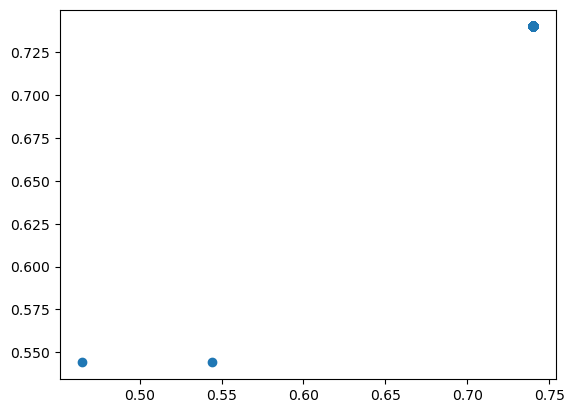

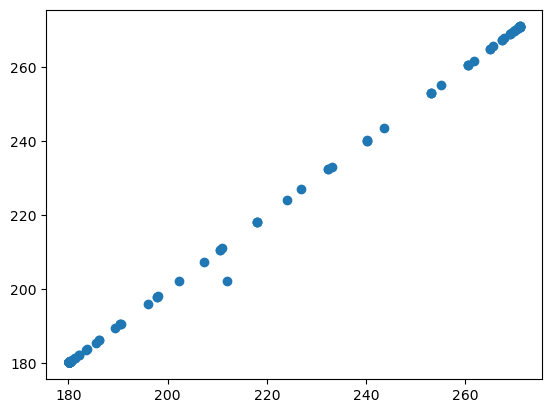

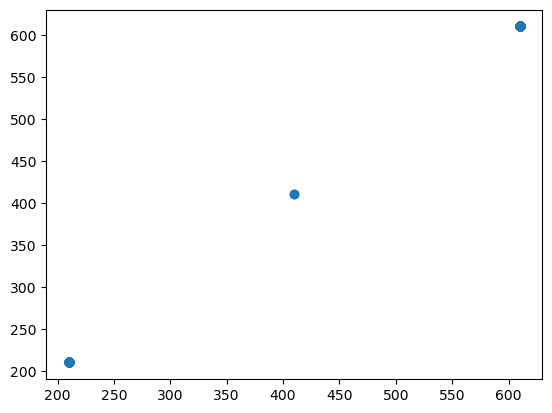

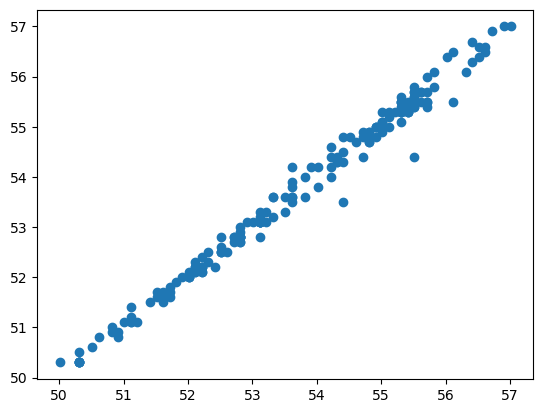

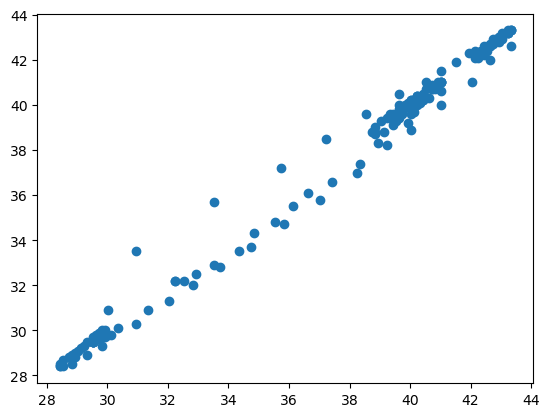

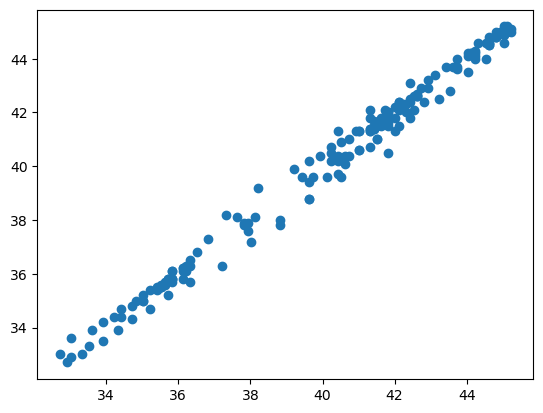

Avg loss MSE: 0.153306, MAE: 0.119840



In [46]:
testing(test_dataloader, model, loss_fn, loss_fn2)

## PBN

In [47]:
# Load model to device
model = PBNModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

In [48]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 5839475.000000, MAE: 1364.532471
New best model found! Saving model, MSE: 3324493.500000, MAE: 1118.150269
New best model found! Saving model, MSE: 1535880.750000, MAE: 780.133972
New best model found! Saving model, MSE: 447080.125000, MAE: 405.832275
New best model found! Saving model, MSE: 36997.937500, MAE: 127.874001
New best model found! Saving model, MSE: 7664.032715, MAE: 54.902153
New best model found! Saving model, MSE: 916.946777, MAE: 17.493120
New best model found! Saving model, MSE: 738.655090, MAE: 17.505062
New best model found! Saving model, MSE: 246.782166, MAE: 9.975830
New best model found! Saving model, MSE: 55.222019, MAE: 3.546613
New best model found! Saving model, MSE: 55.055725, MAE: 4.631151
New best model found! Saving model, MSE: 12.643735, MAE: 1.960182
New best model found! Saving model, MSE: 5.004445, MAE: 1.243678
New best model found! Saving model, MSE: 4.299962, MAE: 1.350252
New best model found! Saving model, 

In [49]:
model.load_state_dict(torch.load("best_model.pth"))
torch.save(model.state_dict(), "PBN_model.pth")

In [50]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

physics_model.c_hi1 tensor([[-0.0101]], device='mps:0')
physics_model.c_hi2 tensor([[-4.1023e-06]], device='mps:0')
physics_model.c_hi3 tensor([[0.0006]], device='mps:0')
physics_model.c_hi4 tensor([[2.2867]], device='mps:0')
physics_model.c_ho1 tensor([[0.0003]], device='mps:0')
physics_model.c_ho2 tensor([[-0.2101]], device='mps:0')
physics_model.c_ho3 tensor([[0.0455]], device='mps:0')
physics_model.c_co1 tensor([[0.0003]], device='mps:0')
physics_model.c_co2 tensor([[0.0838]], device='mps:0')


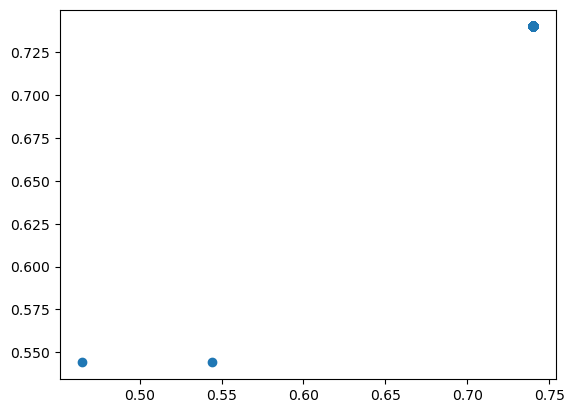

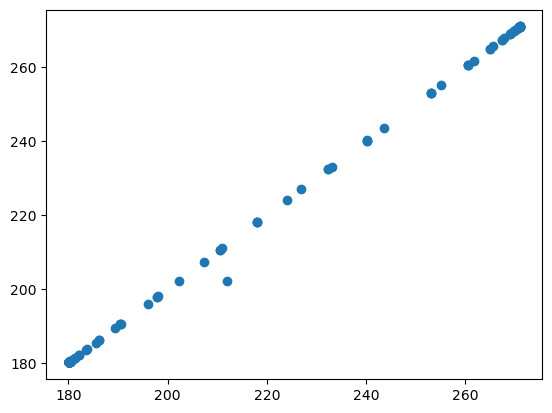

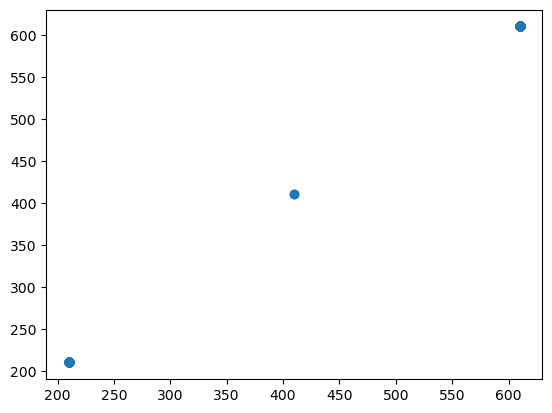

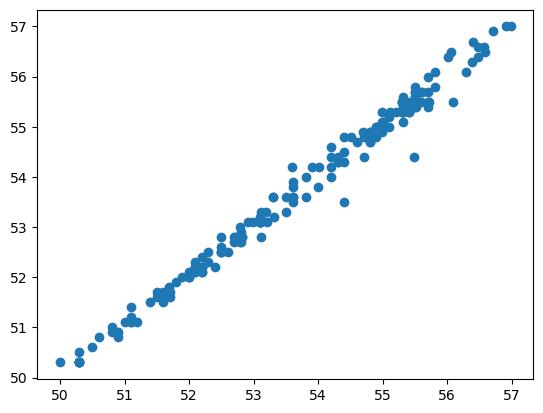

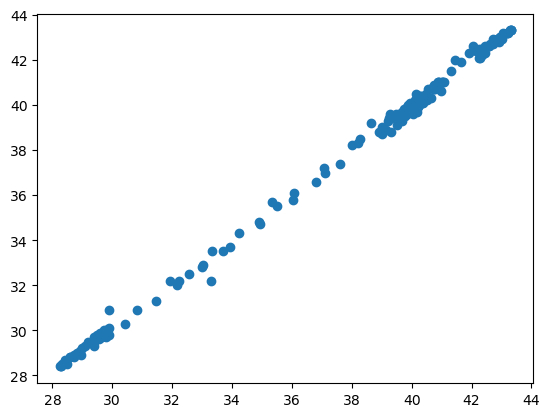

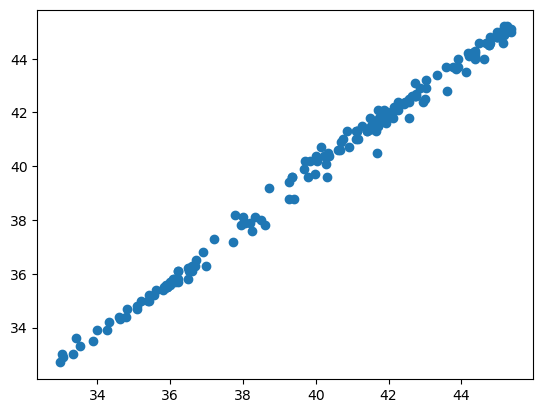

Avg loss MSE: 0.117737, MAE: 0.098135



In [51]:
testing(test_dataloader, model, loss_fn, loss_fn2)

## PBNN

In [52]:
# Load model to device
model = PBNNModel(drop_out=0.3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-1)

In [53]:
epochs = 5000
min_loss = float('inf')
for t in range(epochs):
    if (t + 1) % 100 == 0:  # Print every 100 epochs
        print(f"Epoch {t+1}: ")
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=True)
    else:
        train(train_dataloader, model, loss_fn, optimizer)
        min_loss = test(valid_dataloader, model, loss_fn, loss_fn2, min_loss, print_result=False)
print("Done!")

New best model found! Saving model, MSE: 6035845.000000, MAE: 1545.276367
New best model found! Saving model, MSE: 1770967.375000, MAE: 777.294556
New best model found! Saving model, MSE: 1109244.375000, MAE: 628.500671
New best model found! Saving model, MSE: 929951.125000, MAE: 643.959106
New best model found! Saving model, MSE: 215387.781250, MAE: 289.598907
New best model found! Saving model, MSE: 57450.019531, MAE: 134.248337
New best model found! Saving model, MSE: 56572.539062, MAE: 158.528900
New best model found! Saving model, MSE: 56295.300781, MAE: 151.866837
New best model found! Saving model, MSE: 42697.570312, MAE: 133.800858
New best model found! Saving model, MSE: 25981.802734, MAE: 105.867996
New best model found! Saving model, MSE: 11997.680664, MAE: 66.052902
New best model found! Saving model, MSE: 4898.650879, MAE: 43.722912
New best model found! Saving model, MSE: 2012.895752, MAE: 25.554979
New best model found! Saving model, MSE: 850.463501, MAE: 19.467302
New b

In [54]:
model.load_state_dict(torch.load("best_model.pth"))
torch.save(model.state_dict(), "BPNN_model.pth")

In [55]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

NN_model.linear1.weight tensor([[-0.6430, -0.5731, -0.3892, -0.7680, -0.8159, -0.4352, -0.5579, -0.8374,
         -0.5264, -0.6657],
        [-0.3679, -0.5157, -0.1167, -0.1544, -0.0317, -0.4241, -0.0751, -0.4962,
         -0.2345, -0.0085],
        [-0.1038, -0.0975, -0.2587, -0.5841, -0.2397, -0.1030, -0.0380, -0.0949,
         -0.1070, -0.2262],
        [-0.5106, -0.3050, -0.7790, -0.7518, -0.7471, -0.5351, -0.5162, -0.8595,
         -0.3807, -0.4796],
        [-0.0798,  0.1617, -0.2595, -0.1212,  0.1079, -0.1271, -0.0525,  0.1895,
          0.0214, -0.0311],
        [-0.7679, -0.6997, -0.8834, -0.2744, -0.6502, -0.2958, -0.2797, -0.3826,
         -0.6446, -0.6420],
        [-0.4791, -0.5957, -0.8986, -0.5598, -0.8710, -0.2674, -0.8318, -0.4565,
         -0.3974, -0.3342],
        [-0.3245, -0.4312, -0.5790, -0.5000, -0.6359, -0.6654, -0.3544, -0.5413,
         -0.6613, -0.7849],
        [-0.5051, -0.3666, -0.8154, -0.3596, -0.6958, -0.4975, -0.6794, -0.6951,
         -0.6968, -0.53

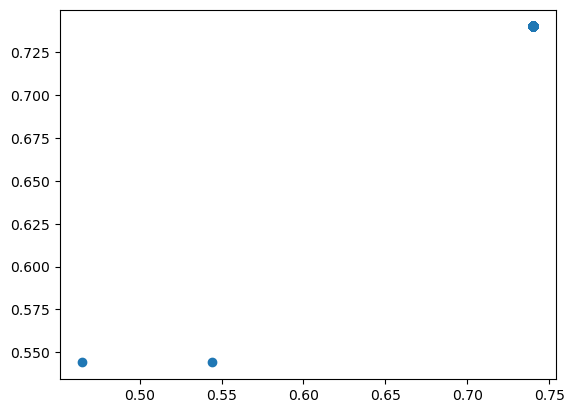

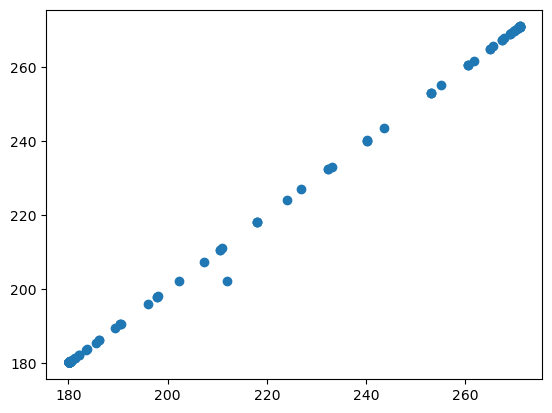

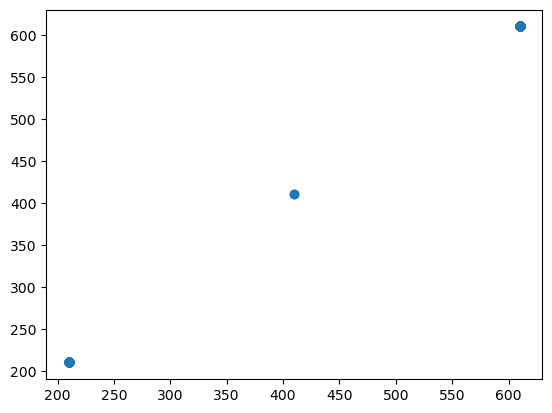

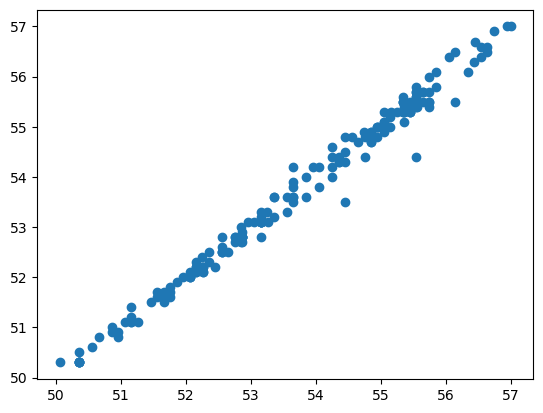

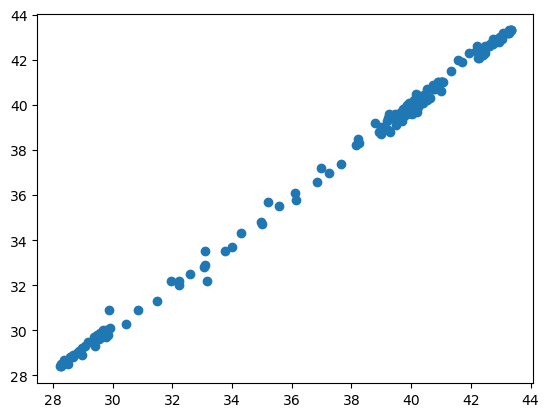

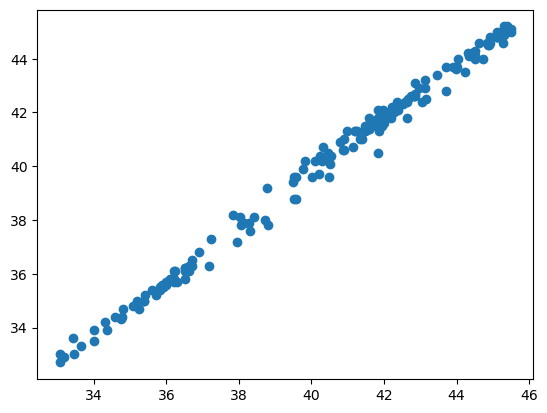

Avg loss MSE: 0.124363, MAE: 0.108313



In [56]:
testing(test_dataloader, model, loss_fn, loss_fn2)